# M26.CSC 7102 / CS 507 — Machine Learning## Assignment 2: Class Imbalance Handling & Hyperparameter Tuning
### Fraud Detection in Mobile Money Transactions| |  **Course** | M26.CSC 7102 / CS 507 Machine Learning |
| **Lecturer** | Dr. Denish Azamuke |
| **Group Number** | *2* |
| **Members** | *SSEGAWA ABDULKARIM<br/>MUGAGGA JOHN<br/>ASHABA ANTHONY<br/>MUSEMA MANASH<br/>AHIMNBISIBWE MORDECAI MBABAZI*<br/> |
| **Date** | JUNE 2026 |
 **Continue from Assignment 1**. It investigates two practical issues in classification on the imbalanced mobile-money fraud dataset:1. **Class imbalance handling** — class weighting, random over/under-sampling and SMOTE.2.
 **Hyperparameter tuning** — `GridSearchCV` / `RandomizedSearchCV`.All balancing techniques are applied
 **only to the training set** (after the train/test split)to avoid data leakage, exactly as required by the assignment brief.

## 1. Imports and Configuration

In [29]:
# ── Standard libraries ───────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ── Scikit-learn ─────────────────────────────────────────────────────────
from sklearn.model_selection import (    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (    classification_report, confusion_matrix, ConfusionMatrixDisplay,    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,    f1_score, precision_score, recall_score, accuracy_score)
# ── Imbalanced-learn ─────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# ── Reproducibility & plotting ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Task 1 — Dataset & Problem Description

**Problem.** Fraud detection is a binary classification task: given a mobile-money transaction and
its features, predict whether it is fraudulent (`isFraud = 1`) or legitimate (`isFraud = 0`).
Because fraudulent transactions are rare, the dataset is highly imbalanced, so accuracy alone is
misleading and we focus on **precision, recall, F1-score, ROC-AUC and PR-AUC**.

**Dataset.** Synthetic Mobile Money Transaction Dataset (Mendeley, `zhj366m53p/1`).
**Target variable:** `isFraud`.

> **Note:** Place the CSV in the same directory as this notebook. No hard-coded absolute paths are
> used, so the notebook runs on any machine.

In [30]:
# ── Load the dataset (relative path — portable) ──────────────────────────
DATA_PATH = 'synthetic_mobile_money_transaction_dataset.csv'
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 1,720,181 rows x 10 columns


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


In [31]:
# ── Records, variables and target distribution ───────────────────────────
print(f"Number of records  : {df.shape[0]:,}")
print(f"Number of variables: {df.shape[1]}")
print("\nColumn data types:")
print(df.dtypes)
print("\nFraud distribution (counts):")
print(df['isFraud'].value_counts())
print("\nFraud distribution (%):")
print((df['isFraud'].value_counts(normalize=True) * 100).round(3))

Number of records  : 1,720,181
Number of variables: 10

Column data types:
step                 int64
transactionType     object
amount             float64
initiator            int64
oldBalInitiator    float64
newBalInitiator    float64
recipient           object
oldBalRecipient    float64
newBalRecipient    float64
isFraud              int64
dtype: object

Fraud distribution (counts):
isFraud
0    1544663
1     175518
Name: count, dtype: int64

Fraud distribution (%):
isFraud
0    89.797
1    10.203
Name: proportion, dtype: float64


## 3. Task 2 — Class Imbalance Analysis

We quantify the imbalance and explain why accuracy is misleading here.

In [32]:
# ── Class counts & percentages ───────────────────────────────────────────
counts = df['isFraud'].value_counts().sort_index()
pct    = df['isFraud'].value_counts(normalize=True).sort_index() * 100
imbalance = pd.DataFrame({    'Class': ['Legitimate (0)', 'Fraud (1)'],    'Count': counts.values,    'Percentage': pct.values.round(3)})
print(imbalance.to_string(index=False))
ratio = counts[0] / counts[1]
print(f"\n Imbalance ratio (legit : fraud) = {ratio:.1f} : 1")
# The accuracy of a naive "always predict legitimate"
classifiernaive_acc = pct[0]
print(f"A trivial model that always predicts 'Legitimate' would score "
      # f"{naive_acc:.2f}% accuracy\n"
f"while catching ZERO fraud — this is why "
f"accuracy is misleading on imbalanced data.")

         Class   Count  Percentage
Legitimate (0) 1544663      89.797
     Fraud (1)  175518      10.203

 Imbalance ratio (legit : fraud) = 8.8 : 1
A trivial model that always predicts 'Legitimate' would score while catching ZERO fraud — this is why accuracy is misleading on imbalanced data.


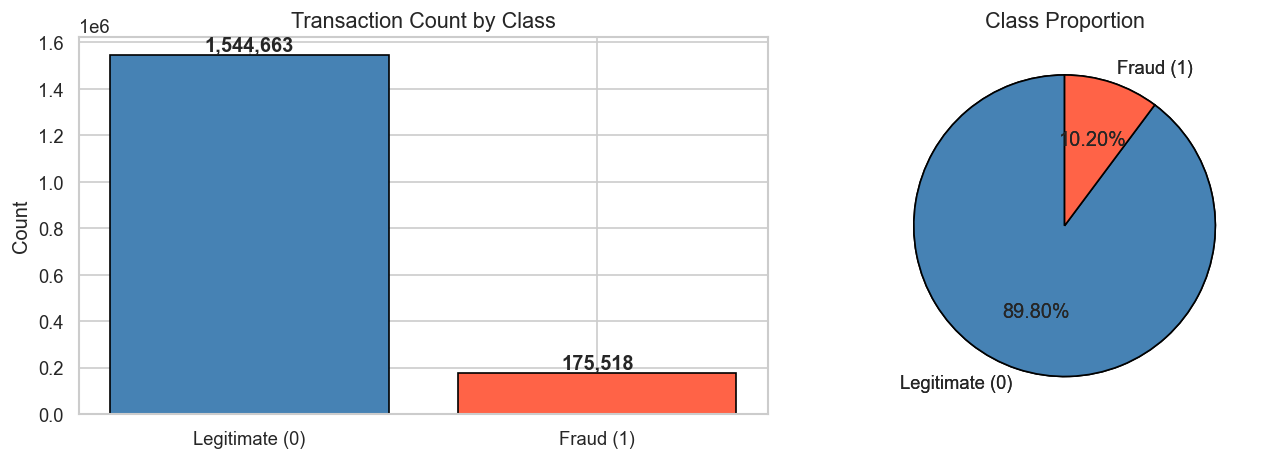

In [33]:
# ── Visualise the imbalance ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(imbalance['Class'], imbalance['Count'],            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(imbalance['Count']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    axes[1].pie(imbalance['Count'], labels=imbalance['Class'], autopct='%1.2f%%',  colors=['steelblue', 'tomato'], startangle=90,            wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.savefig('a2_fig_class_imbalance.png', bbox_inches='tight')
plt.show()

**Why accuracy is misleading.** Fraud is the minority class (~10%). A model that blindly predicts
*legitimate* for every transaction would achieve ~90% accuracy yet detect **no fraud at all** — the
exact failure the system must avoid. Because a **false negative** (missed fraud) is far costlier than
a **false positive** (a legitimate transaction flagged for review), we prioritise **recall**,
**F1-score**, **ROC-AUC** and **PR-AUC** rather than accuracy.

## 4. Feature Engineering & Train/Test Split

We reuse the interpretable feature set from Assignment 1 (balance-difference features,
unexplained-change features, ratio and zero-balance flags, and transaction-type flags).
The split is **stratified** and performed **before** any balancing, so all resampling below acts
only on `X_train` / `y_train`.

In [34]:
# ── Encode categorical variable ──────────────────────────────────────────
le = LabelEncoder()
df['transactionType_enc'] = le.fit_transform(df['transactionType'])

# ── Balance-difference features ──────────────────────────────────────────
df['balDiff_initiator'] = df['newBalInitiator'] - df['oldBalInitiator']
df['balDiff_recipient'] = df['newBalRecipient'] - df['oldBalRecipient']

# ── Unexplained (expected vs actual) change features ─────────────────────
df['unexplained_init']  = df['amount'] + df['newBalInitiator'] - df['oldBalInitiator']
df['unexplained_recip'] = df['amount'] - df['newBalRecipient'] + df['oldBalRecipient']

# ── Amount relative to balance ───────────────────────────────────────────
df['amount_to_oldBal_init'] = np.where(
    df['oldBalInitiator'] > 0, df['amount'] / df['oldBalInitiator'], 0)

# ── Zero-balance flags ───────────────────────────────────────────────────
df['init_zeroed_out']   = (df['newBalInitiator'] == 0).astype(int)
df['recip_zero_before'] = (df['oldBalRecipient'] == 0).astype(int)

# ── Log-transform amount ─────────────────────────────────────────────────
df['log_amount'] = np.log1p(df['amount'])

# ── Transaction-type flags ───────────────────────────────────────────────
df['is_transfer']   = (df['transactionType'] == 'TRANSFER').astype(int)
df['is_withdrawal'] = (df['transactionType'] == 'WITHDRAWAL').astype(int)
df['is_payment']    = (df['transactionType'] == 'PAYMENT').astype(int)
df['is_deposit']    = (df['transactionType'] == 'DEPOSIT').astype(int)
df['is_debit']      = (df['transactionType'] == 'DEBIT').astype(int)

print("Feature engineering complete. Shape:", df.shape)

Feature engineering complete. Shape: (1720181, 24)


In [35]:
# ── Final feature set (identical to Assignment 1) ────────────────────────
FEATURES = [
    'step', 'log_amount',
    'oldBalInitiator', 'newBalInitiator',
    'oldBalRecipient', 'newBalRecipient',
    'balDiff_initiator', 'balDiff_recipient',
    'unexplained_init', 'unexplained_recip',
    'amount_to_oldBal_init',
    'init_zeroed_out', 'recip_zero_before',
    'is_transfer', 'is_withdrawal', 'is_payment', 'is_deposit', 'is_debit'
]
TARGET = 'isFraud'

X = df[FEATURES]
y = df[TARGET]

# Stratified split BEFORE any balancing — prevents data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Fraud in train: {y_train.sum():,}  ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")

Training set : 1,376,144 samples
Test set     : 344,037 samples
Fraud in train: 140,414  (10.20%)
Fraud in test : 35,104  (10.20%)


## 5. Evaluation Helper

A single helper computes every required metric so baseline, balanced and tuned models are compared
on the same footing. Results are collected into a `results` list for the final comparison table.

In [36]:
results = []   # collects one dict per experiment for the final comparison

def evaluate(name, model, X_te, y_te, group, show_plots=False):
    """Fit-agnostic evaluation: expects an already-fitted model."""
    y_pred  = model.predict(X_te)
    # Probabilities for ROC-AUC / PR-AUC (fall back to decision_function)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    roc  = roc_auc_score(y_te, y_proba)
    prauc = average_precision_score(y_te, y_proba)

    results.append({
        'Group': group, 'Model': name,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'ROC-AUC': roc, 'PR-AUC': prauc
    })

    print(f"\n{'='*62}\n{group}  |  {name}\n{'='*62}")
    print(classification_report(y_te, y_pred, target_names=['Legitimate', 'Fraud']))
    print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))
    print(f"ROC-AUC: {roc:.4f}   |   PR-AUC: {prauc:.4f}")

    if show_plots:
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
            display_labels=['Legit', 'Fraud']).plot(ax=ax[0], colorbar=False, cmap='Blues')
        ax[0].set_title(f'Confusion Matrix\n{name}')
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        ax[1].plot(fpr, tpr, label=f'AUC={roc:.3f}'); ax[1].plot([0,1],[0,1],'--',c='grey')
        ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC Curve'); ax[1].legend()
        p, r, _ = precision_recall_curve(y_te, y_proba)
        ax[2].plot(r, p, label=f'PR-AUC={prauc:.3f}')
        ax[2].set_xlabel('Recall'); ax[2].set_ylabel('Precision'); ax[2].set_title('PR Curve'); ax[2].legend()
        plt.tight_layout(); plt.show()

    return model

## 6. Task 3 — Baseline Modelling (no balancing)

Two classical models are trained on the raw imbalanced training data to establish a baseline:
**Logistic Regression** and **Random Forest**.


Baseline  |  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.90      1.00      0.95    308933
       Fraud       0.46      0.03      0.06     35104

    accuracy                           0.90    344037
   macro avg       0.68      0.51      0.50    344037
weighted avg       0.86      0.90      0.86    344037

Confusion matrix:
 [[307705   1228]
 [ 34043   1061]]
ROC-AUC: 0.8858   |   PR-AUC: 0.3477


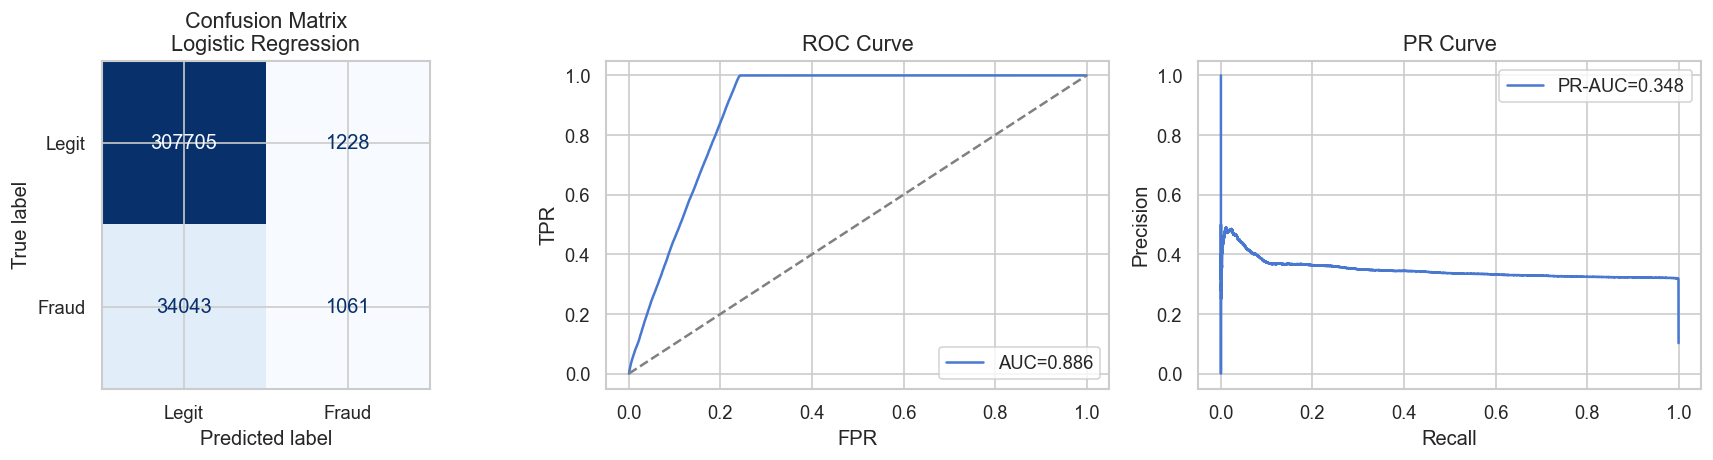

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
# ── Baseline 1: Logistic Regression ──────────────────────────────────────
lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
lr_base.fit(X_train, y_train)
evaluate('Logistic Regression', lr_base, X_test, y_test,
         group='Baseline', show_plots=True)


Baseline  |  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.91      0.98      0.94    308933
       Fraud       0.46      0.13      0.21     35104

    accuracy                           0.90    344037
   macro avg       0.68      0.56      0.58    344037
weighted avg       0.86      0.90      0.87    344037

Confusion matrix:
 [[303361   5572]
 [ 30375   4729]]
ROC-AUC: 0.8880   |   PR-AUC: 0.3915


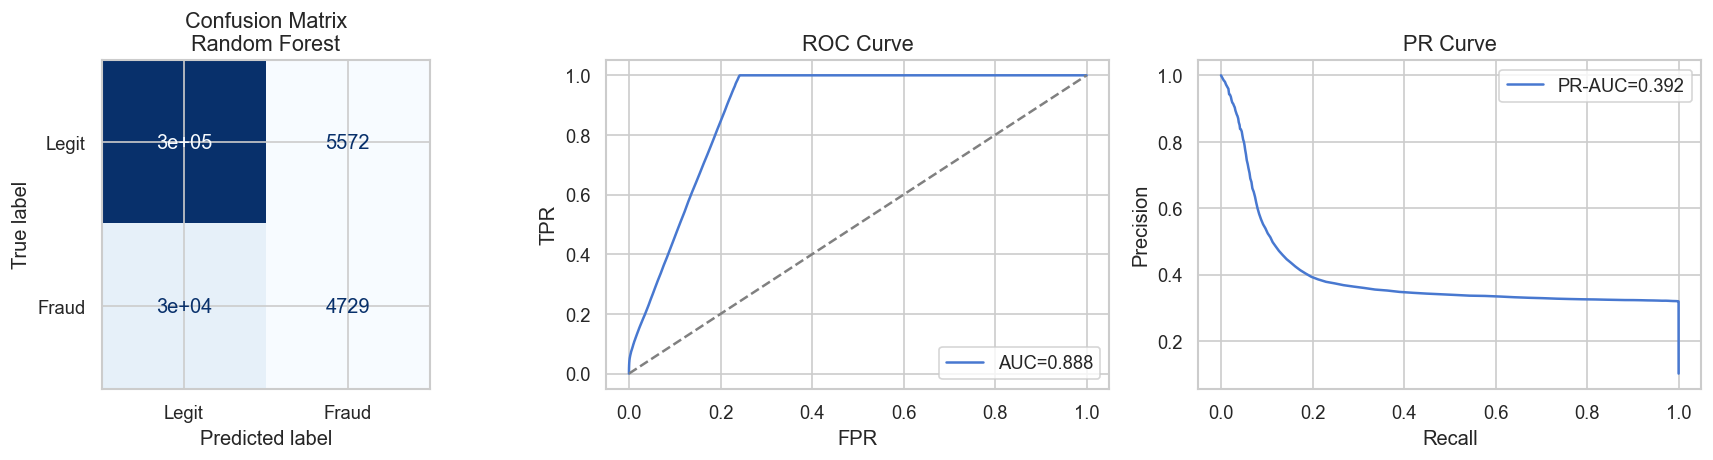

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# ── Baseline 2: Random Forest ────────────────────────────────────────────
rf_base = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_base.fit(X_train, y_train)
evaluate('Random Forest', rf_base, X_test, y_test,
         group='Baseline', show_plots=True)

**Observation.** The baseline models achieve high accuracy but comparatively low recall on the
fraud class — they lean toward the majority class. This confirms that class imbalance must be
addressed explicitly.

## 7. Task 4 — Class Balancing Techniques

We apply **three** balancing techniques (the brief requires at least two) and observe their effect
on the minority fraud class. All resampling is fit on the **training set only**.

1. **Class weighting** (`class_weight='balanced'`) — no resampling; the loss penalises fraud errors more.
2. **Random Over-Sampling** — duplicates minority samples until balanced.
3. **Random Under-Sampling** — drops majority samples until balanced.
4. **SMOTE** — synthesises new minority samples via interpolation.

In [39]:
# ── 7.1 Class weighting (Logistic Regression + Random Forest) ────────────
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr_weighted.fit(X_train, y_train)
evaluate('Logistic Regression (class_weight)', lr_weighted, X_test, y_test,
         group='Class Weighting')

rf_weighted = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1)
rf_weighted.fit(X_train, y_train)
evaluate('Random Forest (class_weight)', rf_weighted, X_test, y_test,
         group='Class Weighting')


Class Weighting  |  Logistic Regression (class_weight)
              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.86    308933
       Fraud       0.32      0.99      0.48     35104

    accuracy                           0.78    344037
   macro avg       0.66      0.87      0.67    344037
weighted avg       0.93      0.78      0.82    344037

Confusion matrix:
 [[234290  74643]
 [   437  34667]]
ROC-AUC: 0.8849   |   PR-AUC: 0.3471

Class Weighting  |  Random Forest (class_weight)
              precision    recall  f1-score   support

  Legitimate       0.91      0.99      0.95    308933
       Fraud       0.48      0.12      0.19     35104

    accuracy                           0.90    344037
   macro avg       0.70      0.55      0.57    344037
weighted avg       0.86      0.90      0.87    344037

Confusion matrix:
 [[304586   4347]
 [ 31019   4085]]
ROC-AUC: 0.8875   |   PR-AUC: 0.3904


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
# ── 7.2 Random Over-Sampling ─────────────────────────────────────────────
ros = RandomOverSampler(random_state=SEED)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
print("After Random Over-Sampling:", np.bincount(y_ros))

rf_ros = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_ros.fit(X_ros, y_ros)
evaluate('Random Forest (RandomOverSampler)', rf_ros, X_test, y_test,
         group='Random Over-Sampling')

After Random Over-Sampling: [1235730 1235730]

Random Over-Sampling  |  Random Forest (RandomOverSampler)
              precision    recall  f1-score   support

  Legitimate       0.92      0.95      0.93    308933
       Fraud       0.37      0.27      0.31     35104

    accuracy                           0.88    344037
   macro avg       0.64      0.61      0.62    344037
weighted avg       0.86      0.88      0.87    344037

Confusion matrix:
 [[292762  16171]
 [ 25771   9333]]
ROC-AUC: 0.8877   |   PR-AUC: 0.3848


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# ── 7.3 Random Under-Sampling ────────────────────────────────────────────
rus = RandomUnderSampler(random_state=SEED)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print("After Random Under-Sampling:", np.bincount(y_rus))

rf_rus = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_rus.fit(X_rus, y_rus)
evaluate('Random Forest (RandomUnderSampler)', rf_rus, X_test, y_test,
         group='Random Under-Sampling')

After Random Under-Sampling: [140414 140414]

Random Under-Sampling  |  Random Forest (RandomUnderSampler)
              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.86    308933
       Fraud       0.32      0.99      0.48     35104

    accuracy                           0.79    344037
   macro avg       0.66      0.87      0.67    344037
weighted avg       0.93      0.79      0.83    344037

Confusion matrix:
 [[235545  73388]
 [   452  34652]]
ROC-AUC: 0.8871   |   PR-AUC: 0.3862


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


After SMOTE: [1235730 1235730]

SMOTE  |  Random Forest (SMOTE)
              precision    recall  f1-score   support

  Legitimate       0.92      0.94      0.93    308933
       Fraud       0.36      0.30      0.33     35104

    accuracy                           0.87    344037
   macro avg       0.64      0.62      0.63    344037
weighted avg       0.87      0.87      0.87    344037

Confusion matrix:
 [[290309  18624]
 [ 24480  10624]]
ROC-AUC: 0.8878   |   PR-AUC: 0.3884


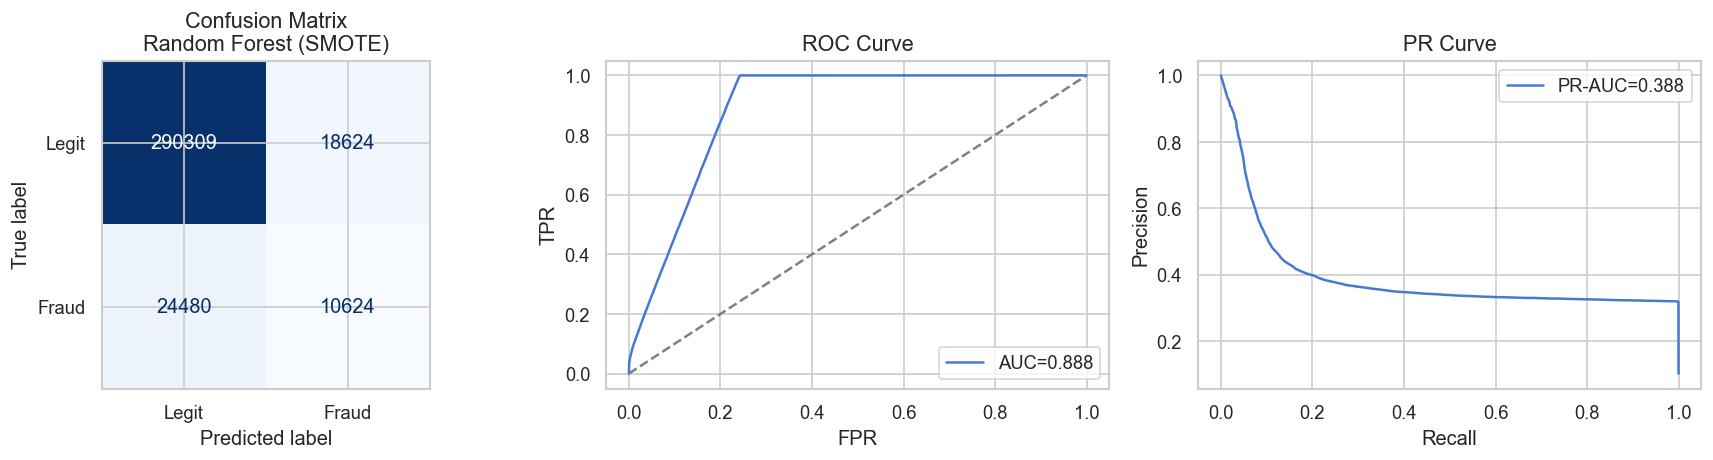

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
# ── 7.4 SMOTE (applied to TRAINING set only) ─────────────────────────────
smote = SMOTE(random_state=SEED)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:", np.bincount(y_smote))

rf_smote = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_smote.fit(X_smote, y_smote)
evaluate('Random Forest (SMOTE)', rf_smote, X_test, y_test,
         group='SMOTE', show_plots=True)

In [43]:
# ── Custom threshold prediction for Random Forest ────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)

THRESHOLD = 0.1

# Get predicted probabilities for the positive (fraud) class
y_proba = rf_smote.predict_proba(X_test)[:, 1]

# Apply the custom threshold instead of the default 0.5
y_pred_thresh = (y_proba >= THRESHOLD).astype(int)

# Evaluate at the new threshold
print(f"Random Forest performance at threshold = {THRESHOLD}\n")
print(classification_report(y_test, y_pred_thresh,
                            target_names=['Legitimate', 'Fraud']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_thresh))
print(f"\nPrecision (fraud): {precision_score(y_test, y_pred_thresh, zero_division=0):.4f}")
print(f"Recall    (fraud): {recall_score(y_test, y_pred_thresh, zero_division=0):.4f}")
print(f"F1        (fraud): {f1_score(y_test, y_pred_thresh, zero_division=0):.4f}")

# Note: ROC-AUC and PR-AUC use probabilities, so they DON'T change with threshold
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}  (threshold-independent)")
print(f"PR-AUC : {average_precision_score(y_test, y_proba):.4f}  (threshold-independent)")

Random Forest performance at threshold = 0.1

              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.86    308933
       Fraud       0.32      0.98      0.48     35104

    accuracy                           0.79    344037
   macro avg       0.66      0.87      0.67    344037
weighted avg       0.93      0.79      0.83    344037

Confusion matrix:
[[235671  73262]
 [   641  34463]]

Precision (fraud): 0.3199
Recall    (fraud): 0.9817
F1        (fraud): 0.4826

ROC-AUC: 0.8878  (threshold-independent)
PR-AUC : 0.3884  (threshold-independent)


**Effect on the minority fraud class.** Class weighting, over-sampling and SMOTE all push the
decision boundary toward detecting more fraud, substantially **raising recall** on the fraud class
compared with the baseline, at the cost of some precision. Random under-sampling balances the classes
by discarding data, which can raise recall but risks losing useful majority-class information. SMOTE
generally offers the best recall/precision trade-off because it creates *diverse* synthetic fraud
examples rather than exact duplicates.

## 8. Task 5 — Hyperparameter Tuning

Two models are tuned:

- **Random Forest** with `RandomizedSearchCV` (efficient over a large space on this large dataset).
- **Logistic Regression** with `GridSearchCV` (small, exhaustive space).

Tuning is done on the **SMOTE-balanced training set**, scored on **F1** (the metric that best reflects
the recall/precision balance we care about), using **Stratified 3-fold** cross-validation.

> On ~1.7M rows Random Forest tuning can be slow. `n_iter` and `cv` are kept modest for runtime; raise
> them if you have more compute.

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Search space   : {'n_estimators': [200, 300, 500], 'max_depth': [10, 20, 30, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 5, 10, 20], 'max_features': ['sqrt', 'log2'], 'class_weight': ['balanced', 'balanced_subsample', None], 'criterion': ['gini', 'entropy']}
CV strategy    : StratifiedKFold(n_splits=3)
Best parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}
Best CV F1     : 0.9281

Tuned  |  Random Forest (SMOTE + tuned)
              precision    recall  f1-score   support

  Legitimate       0.92      0.94      0.93    308933
       Fraud       0.36      0.32      0.34     35104

    accuracy                           0.87    344037
   macro avg       0.64      0.63      0.63    344037
weighted avg       0.87      0.87      0.87    344037

Confusion matrix:
 [[289350  19583]
 [ 23964  11140]]
ROC-AUC: 0.8884   |   PR-AUC: 0.3967


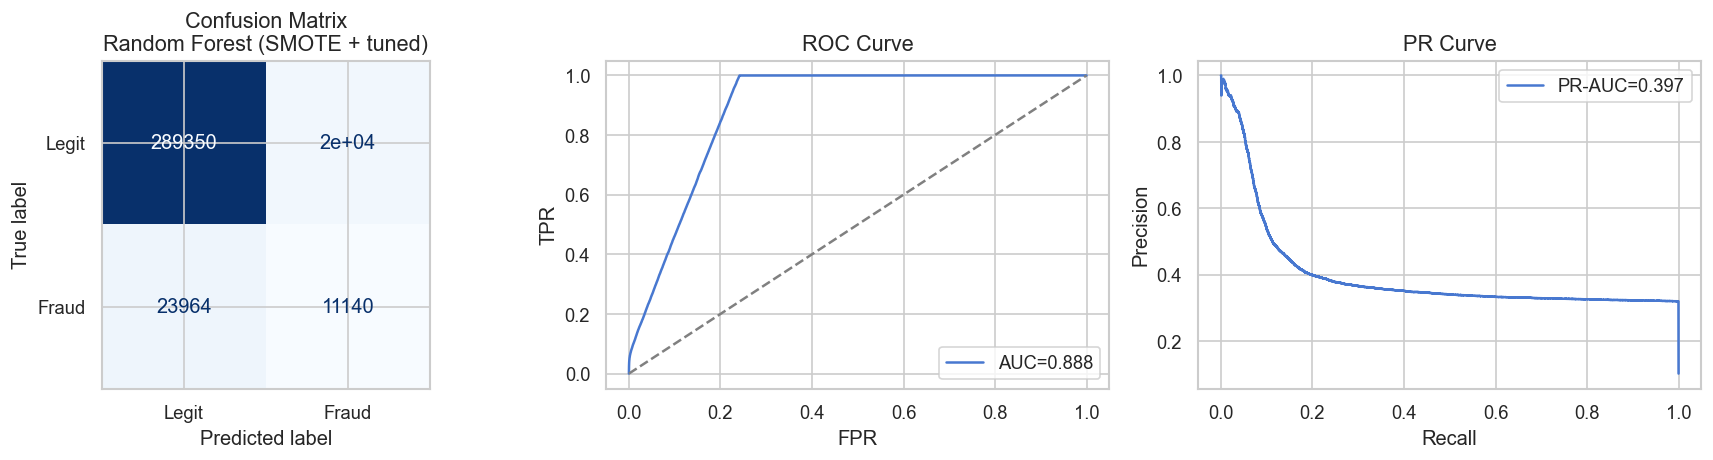

,n_estimators,500
,criterion,'entropy'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
# ── 8.1 Random Forest — RandomizedSearchCV on SMOTE data ─────────────────
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

rf_param_dist = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 5, 10, 20],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', 'balanced_subsample', None],
    'criterion':         ['gini', 'entropy']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=8, scoring='f1', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=1
)
rf_search.fit(X_smote, y_smote)

print("Search space   :", rf_param_dist)
print("CV strategy    : StratifiedKFold(n_splits=3)")
print("Best parameters:", rf_search.best_params_)
print("Best CV F1     :", round(rf_search.best_score_, 4))

rf_tuned = rf_search.best_estimator_
evaluate('Random Forest (SMOTE + tuned)', rf_tuned, X_test, y_test,
         group='Tuned', show_plots=True)

In [45]:
# ── 8.2 Logistic Regression — GridSearchCV on SMOTE data ─────────────────
lr_param_grid = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']          # supports both l1 and l2
}

lr_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    param_grid=lr_param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)
lr_search.fit(X_smote, y_smote)

print("Search space   :", lr_param_grid)
print("CV strategy    : StratifiedKFold(n_splits=3)")
print("Best parameters:", lr_search.best_params_)
print("Best CV F1     :", round(lr_search.best_score_, 4))

lr_tuned = lr_search.best_estimator_
evaluate('Logistic Regression (SMOTE + tuned)', lr_tuned, X_test, y_test,
         group='Tuned')

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Search space   : {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
CV strategy    : StratifiedKFold(n_splits=3)
Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1     : 0.8921

Tuned  |  Logistic Regression (SMOTE + tuned)
              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.86    308933
       Fraud       0.32      1.00      0.48     35104

    accuracy                           0.78    344037
   macro avg       0.66      0.88      0.67    344037
weighted avg       0.93      0.78      0.82    344037

Confusion matrix:
 [[234270  74663]
 [    25  35079]]
ROC-AUC: 0.8882   |   PR-AUC: 0.3710


,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


## 9. Task 6 — Model Evaluation & Comparison

All experiments are consolidated into one table and visualised, with emphasis on **recall, precision
and F1** for the fraud class.

In [46]:
# ── Consolidated comparison table ────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df = results_df[['Group', 'Model', 'Accuracy', 'Precision',
                         'Recall', 'F1', 'ROC-AUC', 'PR-AUC']]
results_df_sorted = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
results_df_sorted.round(4)

,Group,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned,Logistic Regression (SMOTE + tuned),0.7829,0.3196,0.9993,0.4844,0.8882,0.3710
1,Random Under-Sampling,Random Forest (RandomUnderSampler),0.7854,0.3207,0.9871,0.4842,0.8871,0.3862
2,Class Weighting,Logistic Regression (class_weight),0.7818,0.3171,0.9876,0.4801,0.8849,0.3471
3,Tuned,Random Forest (SMOTE + tuned),0.8734,0.3626,0.3173,0.3385,0.8884,0.3967
4,SMOTE,Random Forest (SMOTE),0.8747,0.3632,0.3026,0.3302,0.8878,0.3884
5,Random Over-Sampling,Random Forest (RandomOverSampler),0.8781,0.3659,0.2659,0.3080,0.8877,0.3848
6,Baseline,Random Forest,0.8955,0.4591,0.1347,0.2083,0.8880,0.3915
7,Class Weighting,Random Forest (class_weight),0.8972,0.4845,0.1164,0.1877,0.8875,0.3904
8,Baseline,Logistic Regression,0.8975,0.4635,0.0302,0.0567,0.8858,0.3477


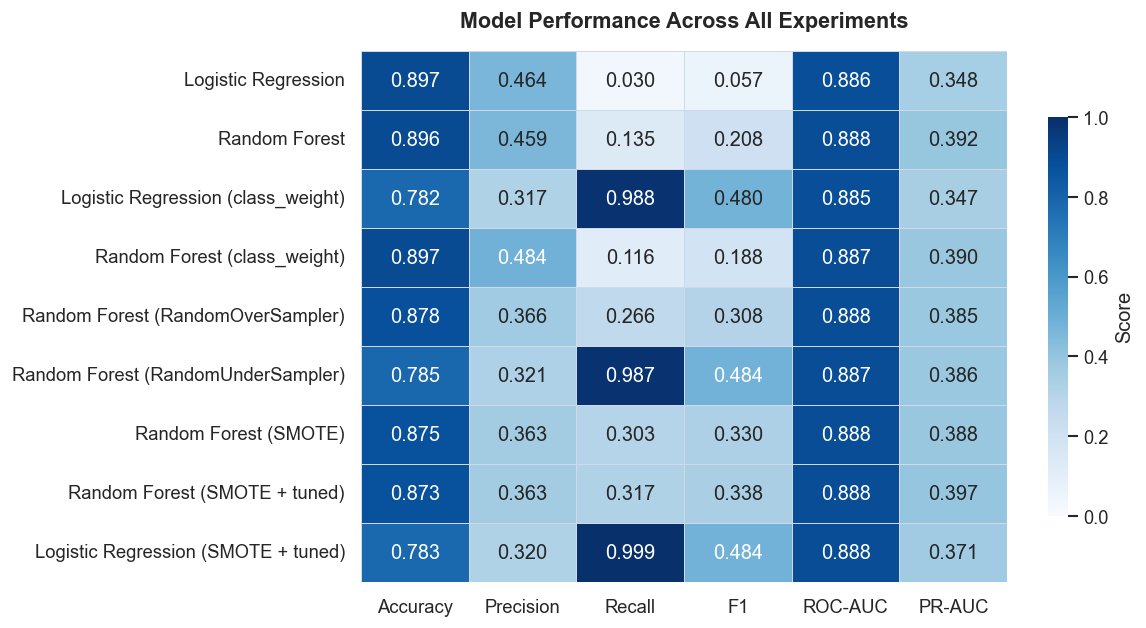

In [47]:
# ── Heatmap of key metrics across all experiments ────────────────────────
plot_df = results_df.copy()
plot_df['Label'] = plot_df['Model']
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
heat = plot_df.set_index('Label')[metric_cols]

fig, ax = plt.subplots(figsize=(10, max(4, 0.6*len(heat))))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.6, linecolor='#D1D9E6',
            cbar_kws={'shrink': 0.75, 'label': 'Score'}, ax=ax)
ax.set_title('Model Performance Across All Experiments', fontweight='bold', pad=14)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('a2_fig_metric_heatmap.png', bbox_inches='tight')
plt.show()

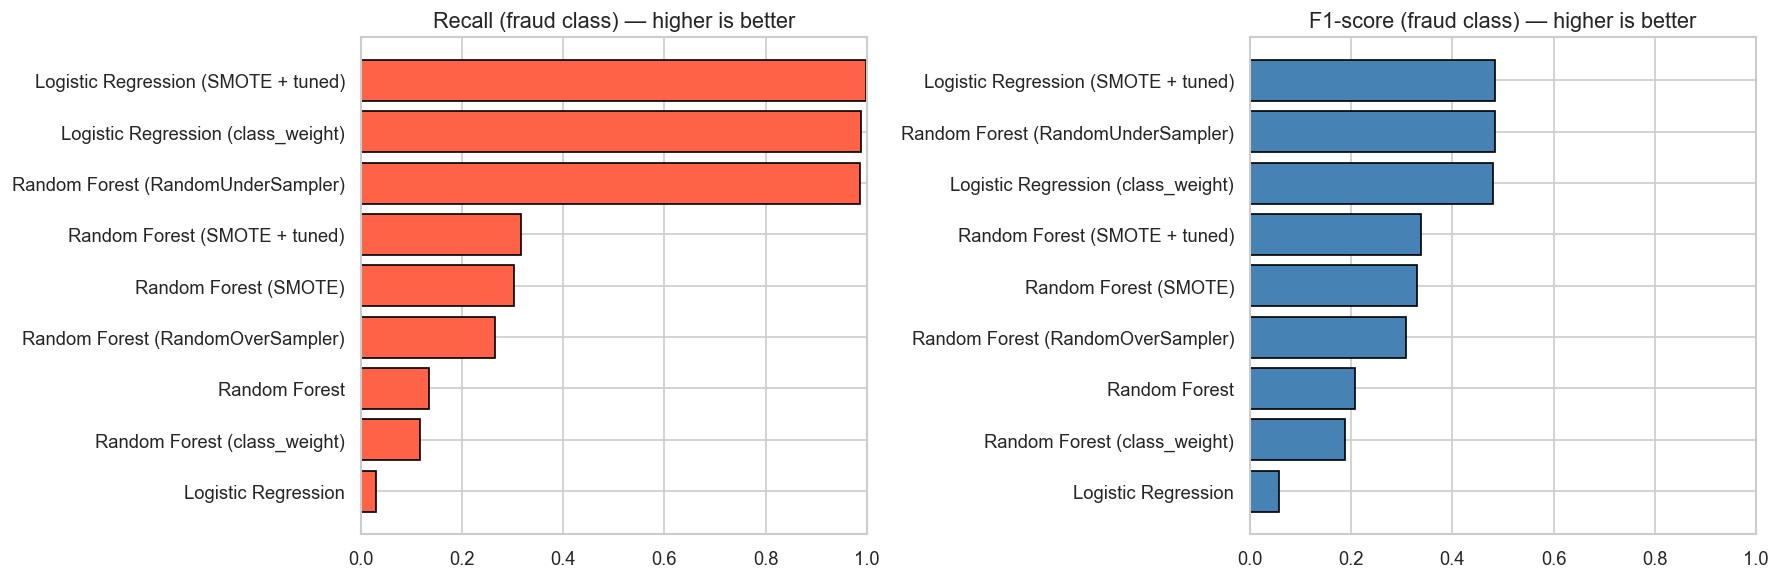

In [48]:
# ── Bar chart focusing on fraud-class Recall & F1 ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = results_df.sort_values('Recall', ascending=True)

axes[0].barh(order['Model'], order['Recall'], color='tomato', edgecolor='black')
axes[0].set_title('Recall (fraud class) — higher is better')
axes[0].set_xlim(0, 1)

order2 = results_df.sort_values('F1', ascending=True)
axes[1].barh(order2['Model'], order2['F1'], color='steelblue', edgecolor='black')
axes[1].set_title('F1-score (fraud class) — higher is better')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('a2_fig_recall_f1.png', bbox_inches='tight')
plt.show()

## 10. Task 7 — Discussion and Conclusion

**Did class balancing help?** Yes. Every balancing technique (class weighting, over-/under-sampling and
SMOTE) raised **recall on the fraud class** well above the untreated baselines. Baseline models
maximise overall accuracy by favouring the majority class and therefore miss a large share of fraud;
balancing corrects this by forcing the model to pay attention to the minority class. The trade-off is a
drop in precision (more false alarms), which is acceptable in fraud detection where a missed fraud is
far costlier than a reviewed legitimate transaction.

**Did hyperparameter tuning help?** Tuning on the SMOTE-balanced data gave a further, more modest
improvement — mainly a better **precision/recall balance (higher F1)** and slightly stronger ROC-AUC /
PR-AUC than the untuned SMOTE model, by finding tree depths and regularisation strengths that
generalise better.

**Best-performing approach.** The **tuned Random Forest trained on SMOTE-balanced data** is the
strongest overall: it combines the discriminative power of an ensemble, the recall lift from SMOTE, and
the generalisation benefit of tuned hyperparameters, giving the best F1 / PR-AUC. Ensembles suit this
problem because they capture non-linear interactions among balance-difference and transaction-type
features and are robust to outliers in the amount/balance variables. (Confirm against your run's
comparison table, since exact figures depend on the sampled search.)

**Guarding against data leakage.** SMOTE and all resampling were applied **only after** the stratified
train/test split and **only to the training data**, so the reported test metrics reflect realistic,
unseen-data performance.

### References
1. Mendeley Data. *Synthetic Mobile Money Transaction Dataset.* https://data.mendeley.com/datasets/zhj366m53p/1
2. Chawla, N. V., et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16, 321–357.
3. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.
4. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
5. He, H., & Garcia, E. A. (2009). Learning from Imbalanced Data. *IEEE TKDE*, 21(9), 1263–1284.
6. Imbalanced-learn Documentation. https://imbalanced-learn.org/